The following code uses machine learning to train a Convolutional Neural Network (CNN) on a large dataset of Brazilian coins and then applies transfer learning to train on a small dataset of UK coins. The goal is to achieve an accuracy for the UK coins similar to the accuracy of the Brazilian coins.


Download the Brazilian coins dataset.

In [ ]:
!wget https://edshare.gcu.ac.uk/id/document/61314 \
      -O /content/Brazilian_coins_dataset_ClassSplit.zip

--2025-04-14 18:57:07--  https://edshare.gcu.ac.uk/id/document/61314
Resolving edshare.gcu.ac.uk (edshare.gcu.ac.uk)... 46.22.140.159
Connecting to edshare.gcu.ac.uk (edshare.gcu.ac.uk)|46.22.140.159|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://edshare.gcu.ac.uk/9958/1/Brazilian_coins_dataset_ClassSplit.zip [following]
--2025-04-14 18:57:08--  https://edshare.gcu.ac.uk/9958/1/Brazilian_coins_dataset_ClassSplit.zip
Reusing existing connection to edshare.gcu.ac.uk:443.
HTTP request sent, awaiting response... 200 OK
Length: 33540668 (32M) [application/zip]
Saving to: ‘/content/Brazilian_coins_dataset_ClassSplit.zip’

/content/Brazilian_ 100%[===================>]  31.99M  14.5MB/s    in 2.2s    

2025-04-14 18:57:11 (14.5 MB/s) - ‘/content/Brazilian_coins_dataset_ClassSplit.zip’ saved [33540668/33540668]



The zip file is next extracted to the current directory, producing `train` and `validation` subdirectories.

In [ ]:
import os
import zipfile
#Extract it. Directories structure as train/val is created.
local_zip = '/content/Brazilian_coins_dataset_ClassSplit.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('./')
zip_ref.close()
os.remove('./split_in_folders.c') #C code used to re-arrange the original images in subfolders

Define directories:

In [ ]:
base_dir = './'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

There is a total of 765 training images and 300 validation images.

#Show Some Coins

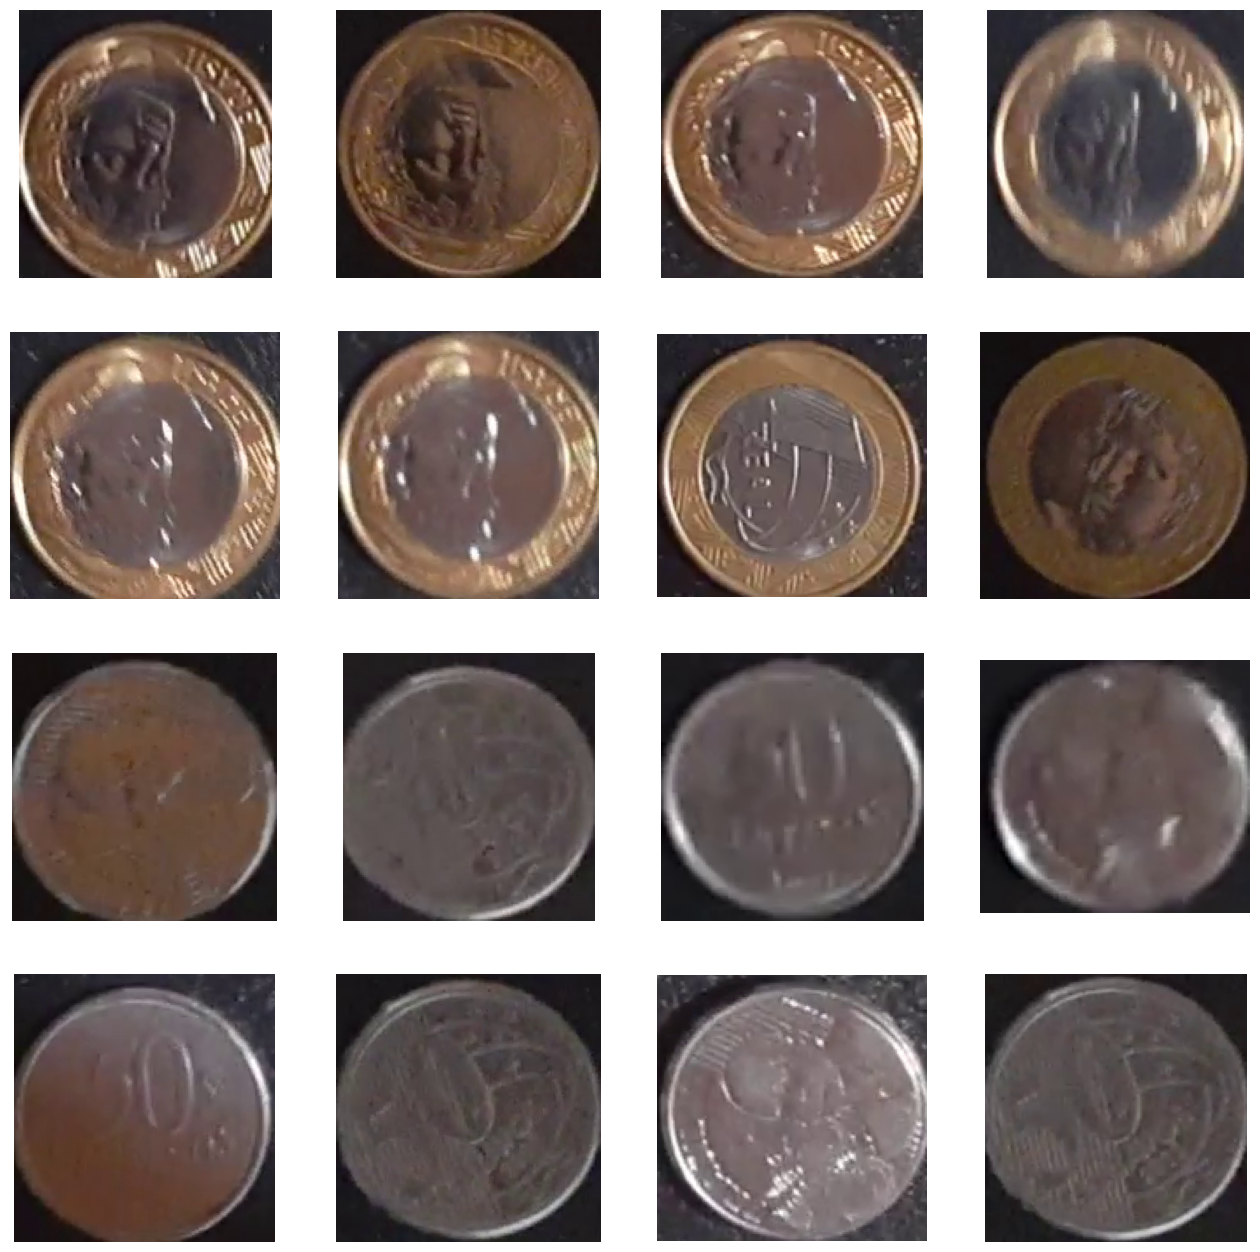

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
nrows = 4
ncols = 4
#Directory with training 50 pictures
train_050_dir = os.path.join(train_dir, '050')
#Directory with training 100 pictures
train_100_dir = os.path.join(train_dir, '100')
train_100_fnames = os.listdir(train_100_dir)
train_050_fnames = os.listdir(train_050_dir)
pic_index = 0 #Index for iterating over images
#Set up matplotlib fig, and size it to fit 4x4 pics
fig = plt.gcf()
fig.set_size_inches(ncols * 4, nrows * 4)
pic_index += 8
next_100_pix = [os.path.join(train_100_dir, fname)
                for fname in train_100_fnames[pic_index-8:pic_index]]
next_050_pix = [os.path.join(train_050_dir, fname)
                for fname in train_050_fnames[pic_index-8:pic_index]]
for i, img_path in enumerate(next_100_pix+next_050_pix):
  #Set up subplot. Subplot indices start at 1
  sp = plt.subplot(nrows, ncols, i + 1)
  sp.axis('Off') #Don't show axes or gridlines
  img = mpimg.imread(img_path)
  plt.imshow(img)
plt.show()

## Build a Small ConvNet from Scratch

Resize all images to 100x100 pixels, which will be the input size to the neural network.<p>
Define a shallow network.<p>
The convolutional layers are extracting features to classify some coins.<p>


In [ ]:
!pip install tensorflow
from tensorflow import keras
from keras._tf_keras.keras import layers
from keras._tf_keras.keras import Model
from keras._tf_keras.keras import regularizers


In [ ]:
#Input feature map is 100x100x3 colour channels
img_input = layers.Input(shape=(100, 100, 3))

#First convolution extracts 32 filters that are 3x3
#Convolution is followed by max-pooling layer with a 2x2 window
x = layers.Conv2D(32, 3, activation='relu')(img_input)
x = layers.MaxPooling2D(2)(x)

#Second convolution extracts 64 filters that are 3x3
#Convolution is followed by max-pooling layer with a 2x2 window
x = layers.Conv2D(64, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)

#Third convolution extracts 128 filters that are 3x3
#Convolution is followed by max-pooling layer with a 2x2 window
x = layers.Convolution2D(128, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)

The feature map is flattened and a couple of dense fully connected layers are added. The final one needs 5 outputs since it's a 5-class classification.<p>
A sigmoid activation can only handle 2 classes so `ReLU` activation is used instead.
Dropout can be added right before the final layer to improve generalisation/reduce overfitting.

In [ ]:
#Flatten feature map to a 1D tensor so fully connected layers can be added
x = layers.Flatten()(x)

#Fully connected layer with 256 hidden units and ReLU activation
x = layers.Dense(256, activation='relu')(x)
#Dropout rate of 0.2
x = layers.Dropout(0.2)(x)
#5 nodes for classification
x = layers.Dense(5, activation='softmax')(x)

#Create model:
model = Model(img_input, x)

Summarise the model architecture.

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,371,589 (12.86 MB)

 Trainable params: 3,371,589 (12.86 MB)

 Non-trainable params: 0 (0.00 B)

Configure the specifications for model training, using Keras `model.compile` method.<p>
Categorical crossentropy loss is used instead of binary crossentropy loss, because the final activation cannot be a sigmoid.<p>
Use `RMSprop` optimiser algorithm, learning rate usually 0.001. During training, monitor classification accuracy.

In [ ]:
from keras._tf_keras.keras.optimizers import RMSprop
#Use categorical crossentropy loss
model.compile(loss='categorical_crossentropy', #Loss metric
              optimizer=RMSprop(learning_rate=0.001), #Optimiser, initial learning rate
              metrics=['acc']) #Metrics to monitor during training ('acc' = accuracy)

### Data Preprocessing

Data generators are setup which will read pictures in source folders, convert them to `float32` tensors, and feed them to the network. Since data is split into train and validation folders, there is one generator for the training images and one for the validation images.<p>
The generators will yield batches of "B" images and their labels.<p>
Images are preprocessed by normalising the pixel values to be in the 0.0 to 1.0 range by dividing by 255. Data augmentation is used to account for more variability. Rotations are important as new coins may appear rotated during future inference.<p>
In Keras this is done via the `keras.preprocessing.image.ImageDataGenerator` class.

In [ ]:
from keras._tf_keras.keras.preprocessing.image import ImageDataGenerator
#All images will be rescaled by 1./255 and augmented
train_datagen = ImageDataGenerator(
    rescale=1./255,
    #Data-augmentation parameters:
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=1./255) #Do not augment validation
B = 15 #Batch size
#Flow training images in batches of "B" using train_datagen generator
train_generator = train_datagen.flow_from_directory(
        train_dir, #This is the source directory for training images
        target_size = (100, 100), #All images will be resized to 100x100
        batch_size=B,
        #To use categorical_crossentropy loss, categorical labels are needed
        class_mode='categorical')
#Flow validation images in batches of 20 using val_datagen generator
validation_generator = val_datagen.flow_from_directory(
        validation_dir,
        target_size=(100, 100),
        batch_size=B,
        class_mode='categorical')

Found 765 images belonging to 5 classes.
Found 300 images belonging to 5 classes.


### Training
Train on all 765 images available, for 50 epochs, and validate on all 300 validation images.<p>
The model is overfitting if the training accuracy is significantly better than validation accuracy.


In [ ]:
history = model.fit(
      train_generator,
      steps_per_epoch=765//B,  #765 images = batch_size * steps
      epochs=50,
      validation_data=validation_generator,
      validation_steps=300//B,  #300 images = batch_size * steps
      verbose=2)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
51/51 - 14s - 278ms/step - acc: 0.2601 - loss: 1.6196 - val_acc: 0.2900 - val_loss: 1.4814
Epoch 2/50
51/51 - 3s - 62ms/step - acc: 0.4510 - loss: 1.3753 - val_acc: 0.5200 - val_loss: 1.0665
Epoch 3/50
51/51 - 4s - 72ms/step - acc: 0.5124 - loss: 1.2160 - val_acc: 0.6467 - val_loss: 0.9643
Epoch 4/50
51/51 - 4s - 85ms/step - acc: 0.6000 - loss: 0.9984 - val_acc: 0.6433 - val_loss: 0.7443
Epoch 5/50
51/51 - 3s - 57ms/step - acc: 0.6118 - loss: 0.9376 - val_acc: 0.7067 - val_loss: 0.7082
Epoch 6/50
51/51 - 5s - 103ms/step - acc: 0.6458 - loss: 0.8104 - val_acc: 0.6500 - val_loss: 0.7179
Epoch 7/50
51/51 - 3s - 57ms/step - acc: 0.6523 - loss: 0.8086 - val_acc: 0.7200 - val_loss: 0.7099
Epoch 8/50
51/51 - 6s - 111ms/step - acc: 0.6902 - loss: 0.7553 - val_acc: 0.5300 - val_loss: 1.1303
Epoch 9/50
51/51 - 5s - 90ms/step - acc: 0.6902 - loss: 0.7162 - val_acc: 0.7867 - val_loss: 0.5049
Epoch 10/50
51/51 - 5s - 104ms/step - acc: 0.7137 - loss: 0.7005 - val_acc: 0.6867 - val_loss: 0

Text(0.5, 1.0, 'Training and validation loss')

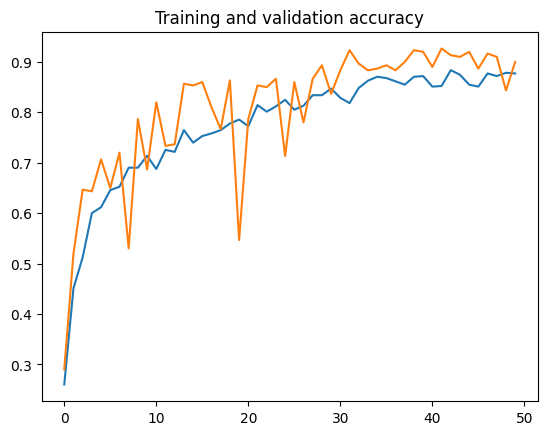

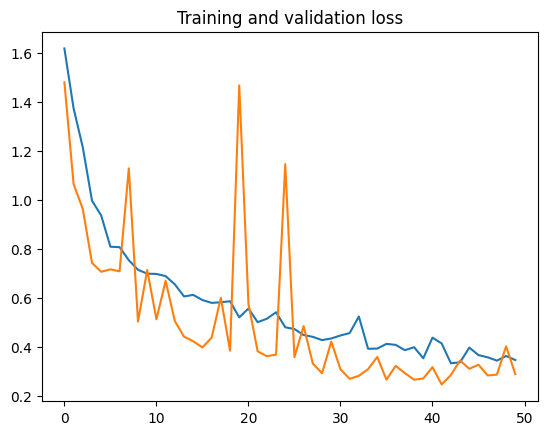

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

#Retrieve a list of accuracy results on training and validation data
#Sets for each training epoch
acc = history.history['acc']
val_acc = history.history['val_acc']

#Retrieve a list of results on training and validation data
#Sets for each training epoch
loss = history.history['loss']
val_loss = history.history['val_loss']

#Get number of epochs
epochs = range(len(acc))

#Plot training and validation accuracy per epoch
plt.plot(epochs, acc)
plt.plot(epochs, val_acc)
plt.title('Training and validation accuracy')

plt.figure()

#Plot training and validation loss per epoch
plt.plot(epochs, loss)
plt.plot(epochs, val_loss)
plt.title('Training and validation loss')

---

#Transfer Learning to UK Coins
There are a very limited number of UK coin examples (just over 300) split in 8 subdirectories, one for each  class. Apply transfer learning from Brazilian coins.

In [ ]:
!wget https://edshare.gcu.ac.uk/id/document/61325 \
      -O /content/UK_coins_ClassSplit.zip

--2025-04-14 19:00:58--  https://edshare.gcu.ac.uk/id/document/61325
Resolving edshare.gcu.ac.uk (edshare.gcu.ac.uk)... 46.22.140.159
Connecting to edshare.gcu.ac.uk (edshare.gcu.ac.uk)|46.22.140.159|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://edshare.gcu.ac.uk/9959/1/UK_coins_Mario_ClassSplit.zip [following]
--2025-04-14 19:00:59--  https://edshare.gcu.ac.uk/9959/1/UK_coins_Mario_ClassSplit.zip
Reusing existing connection to edshare.gcu.ac.uk:443.
HTTP request sent, awaiting response... 200 OK
Length: 2212692 (2.1M) [application/zip]
Saving to: ‘/content/UK_coins_ClassSplit.zip’

/content/UK_coins_C 100%[===================>]   2.11M  2.23MB/s    in 0.9s    

2025-04-14 19:01:00 (2.23 MB/s) - ‘/content/UK_coins_ClassSplit.zip’ saved [2212692/2212692]



In [ ]:
local_zip = '/content/UK_coins_ClassSplit.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('./')
zip_ref.close()
UK_base_dir = './UK_coins_Mario_ClassSplit'

#Show Some UK Coins

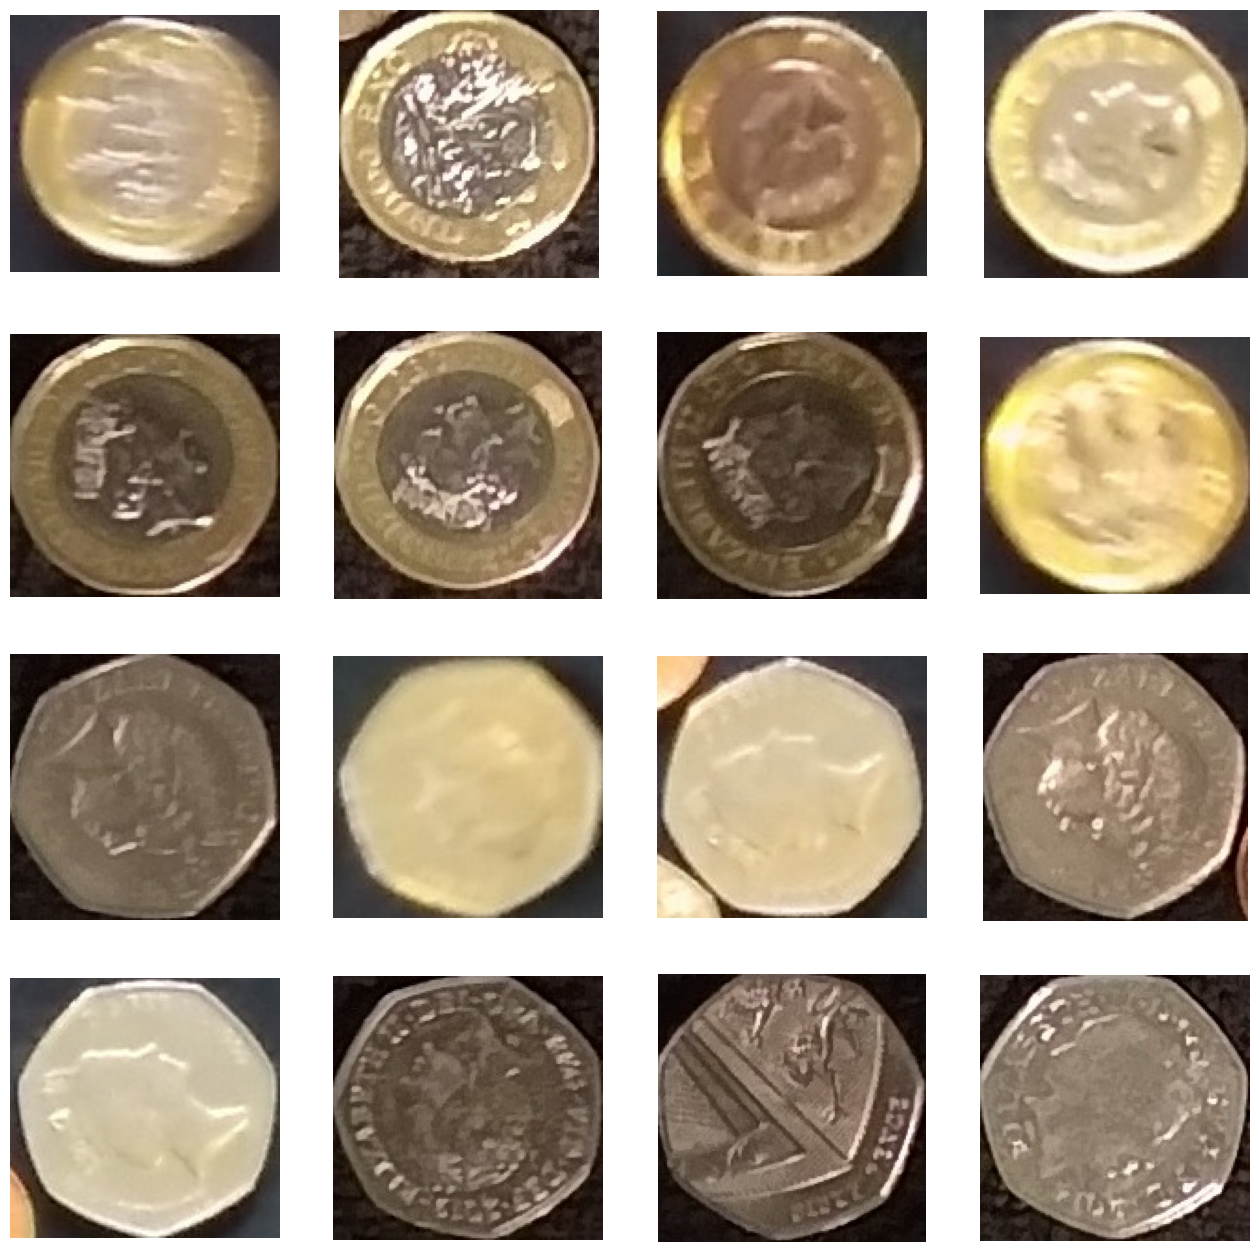

In [ ]:
UK_100_dir = os.path.join(UK_base_dir, '100')
UK_050_dir = os.path.join(UK_base_dir, '050')
nrows = 4
ncols = 4
train_100_fnames = os.listdir(UK_100_dir)
train_050_fnames = os.listdir(UK_050_dir)
pic_index = 0 #Index for iterating over images
#Set up matplotlib fig, and size it to fit 4x4 pics
fig = plt.gcf()
fig.set_size_inches(ncols * 4, nrows * 4)
pic_index += 8
next_100_pix = [os.path.join(UK_100_dir, fname)
                for fname in train_100_fnames[pic_index-8:pic_index]]
next_050_pix = [os.path.join(UK_050_dir, fname)
                for fname in train_050_fnames[pic_index-8:pic_index]]
for i, img_path in enumerate(next_100_pix+next_050_pix):
  #Set up subplot; subplot indices start at 1
  sp = plt.subplot(nrows, ncols, i + 1)
  sp.axis('Off') #Don't show axes or gridlines
  img = mpimg.imread(img_path)
  plt.imshow(img)
plt.show()

Load the training data. There is no seperate train and validation directories this time, therefore an automatic train/validation split is used as determined by the parameter `validation_split`.<p>

In [ ]:
#All images will be rescaled by 1./255 and augmented
UK_datagen = ImageDataGenerator(
    rescale=1./255,
    #Data-augmentation parameters:
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2) #Makes random split, 20% for validation

B = 10 #Batch size
#Extract flow training images in batches of "B" images
UK_train_generator = UK_datagen.flow_from_directory(
        UK_base_dir, #This is the source directory for training images
        target_size = (100, 100), #All images will be resized to 100x100
        batch_size=B,
        subset = 'training',
        class_mode='categorical')
#Extract flow validation images in batches of B images
UK_validation_generator = UK_datagen.flow_from_directory(
        UK_base_dir,
        target_size=(100, 100),
        batch_size=B,
        subset = 'validation',
        class_mode='categorical')

Found 250 images belonging to 8 classes.
Found 59 images belonging to 8 classes.


Freeze all layers of the Brazilian CNN, so they don't get re-trained:

In [ ]:
for layer in model.layers:
  print('freezing ' + layer.name)
  layer.trainable = False

freezing input_layer
freezing conv2d
freezing max_pooling2d
freezing conv2d_1
freezing max_pooling2d_1
freezing conv2d_2
freezing max_pooling2d_2
freezing flatten
freezing dense
freezing dropout
freezing dense_1


Replace the last FC layers right after flattening by new ones. The output needs 8 classes now.<p>
Check layer names to select the desired replacement point.

In [ ]:
replace_point = model.get_layer('flatten')

replace_point = model.get_layer('dense') #Dense layer

replace_point = model.get_layer('dropout') #Dropout layer

#FINAL LAYER NEEDS 8 nodes (one per class)

UKoutput = layers.Dense(8, activation='softmax')(replace_point.output) #8 classes for UK coins

#Create UK coins model:
UKmodel = Model(img_input, UKoutput)

Summary of the updated UK model which should show a number of non-trainable parameters from the frozen layers. The transferred layers should have the same names they had in the original model, added layers will get new names.

In [ ]:
UKmodel.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,372,360 (12.86 MB)

 Trainable params: 2,056 (8.03 KB)

 Non-trainable params: 3,370,304 (12.86 MB)

Compile the new model. Use a reduced learning rate, 1/10 of the original one.

In [ ]:
UKmodel.compile(loss='categorical_crossentropy', #Loss metric
              optimizer=RMSprop(learning_rate=0.001/10), #Decreased learning rate
              metrics=['acc']) #Metrics to monitor during training ('acc' = accuracy)

Train the added layers on the UK coins. There is an assumption that the Brazilian coin features extracted by the frozen layers will also be useful for the UK coins.

In [ ]:
history = UKmodel.fit(
      UK_train_generator,
      steps_per_epoch=250//B,  #250 train images = batch_size * steps
      epochs=50,
      validation_data=UK_validation_generator,
      validation_steps=59//B,  #59 validation images = batch_size * steps
      verbose=2)

Epoch 1/50
25/25 - 4s - 160ms/step - acc: 0.0520 - loss: 3.3358 - val_acc: 0.0600 - val_loss: 2.6101
Epoch 2/50
25/25 - 1s - 35ms/step - acc: 0.0840 - loss: 3.1813 - val_acc: 0.0600 - val_loss: 2.2741
Epoch 3/50
25/25 - 1s - 34ms/step - acc: 0.1080 - loss: 3.0554 - val_acc: 0.0800 - val_loss: 2.3776
Epoch 4/50
25/25 - 1s - 35ms/step - acc: 0.0880 - loss: 2.9753 - val_acc: 0.0600 - val_loss: 2.3330
Epoch 5/50
25/25 - 1s - 49ms/step - acc: 0.1120 - loss: 2.8014 - val_acc: 0.1600 - val_loss: 2.1791
Epoch 6/50
25/25 - 1s - 51ms/step - acc: 0.0920 - loss: 2.7570 - val_acc: 0.2000 - val_loss: 2.1807
Epoch 7/50
25/25 - 1s - 51ms/step - acc: 0.1240 - loss: 2.7037 - val_acc: 0.1400 - val_loss: 2.1492
Epoch 8/50
25/25 - 1s - 34ms/step - acc: 0.1200 - loss: 2.6203 - val_acc: 0.1400 - val_loss: 2.1186
Epoch 9/50
25/25 - 1s - 52ms/step - acc: 0.1280 - loss: 2.6021 - val_acc: 0.2800 - val_loss: 2.1081
Epoch 10/50
25/25 - 3s - 101ms/step - acc: 0.2000 - loss: 2.4701 - val_acc: 0.2200 - val_loss: 2.11

Text(0.5, 1.0, 'Training and validation loss')

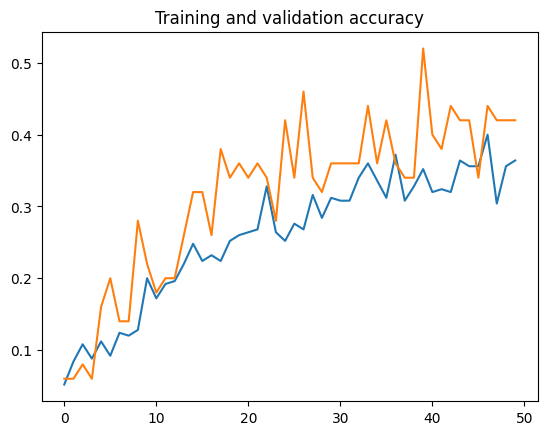

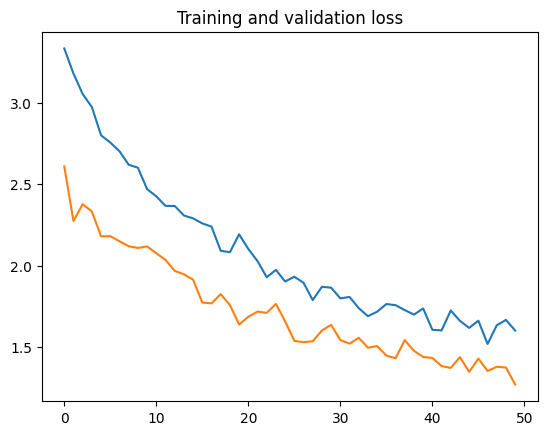

In [ ]:
#Retrieve a list of accuracy results on training and validation data
#Sets for each training epoch
acc = history.history['acc']
val_acc = history.history['val_acc']

#Retrieve a list of results on training and validation data
#Sets for each training epoch
loss = history.history['loss']
val_loss = history.history['val_loss']

#Get number of epochs
epochs = range(len(acc))

#Plot training and validation accuracy per epoch
plt.plot(epochs, acc)
plt.plot(epochs, val_acc)
plt.title('Training and validation accuracy')

plt.figure()

#Plot training and validation loss per epoch
plt.plot(epochs, loss)
plt.plot(epochs, val_loss)
plt.title('Training and validation loss')

Improve by unfreezing the last imported Conv layer and retrain some more with a heavily reduced learning rate, 1/100 of the original.<p>

In [ ]:
unfreeze = False
for layer in UKmodel.layers:
  if layer.name == 'conv2d_2': #First layer to unfreeze
    print('--- unfreezing ---')
    unfreeze = True
  if unfreeze:
    layer.trainable = True
  print(layer.name)

input_layer
conv2d
max_pooling2d
conv2d_1
max_pooling2d_1
--- unfreezing ---
conv2d_2
max_pooling2d_2
flatten
dense
dropout
dense_2


In [ ]:
#Show model again. Compare the number of non-trainable parameters with previous versions
UKmodel.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,374,418 (12.87 MB)

 Trainable params: 3,352,968 (12.79 MB)

 Non-trainable params: 19,392 (75.75 KB)

 Optimizer params: 2,058 (8.04 KB)

Fine-tune with a Stochastic Gradient Descent with a very low learning rate for 60 epochs.

In [ ]:
#As an optimizer, here we will use SGD
#with a very low learning rate (0.0001)
from keras._tf_keras.keras.optimizers import SGD
UKmodel.compile(loss='categorical_crossentropy',
                optimizer=SGD(learning_rate=0.0001, momentum=0.9),
                metrics=['acc'])

In [ ]:
history = UKmodel.fit(
      UK_train_generator,
      steps_per_epoch=250//B, #250 images = batch_size * steps
      epochs=60,
      validation_data=UK_validation_generator,
      validation_steps=59//B, #59 images = batch_size * steps
      verbose=2)

Epoch 1/60
25/25 - 3s - 132ms/step - acc: 0.3480 - loss: 1.6234 - val_acc: 0.4000 - val_loss: 1.3291
Epoch 2/60
25/25 - 1s - 35ms/step - acc: 0.3640 - loss: 1.5958 - val_acc: 0.5000 - val_loss: 1.3012
Epoch 3/60
25/25 - 1s - 35ms/step - acc: 0.3640 - loss: 1.5108 - val_acc: 0.4000 - val_loss: 1.3532
Epoch 4/60
25/25 - 1s - 35ms/step - acc: 0.3880 - loss: 1.4265 - val_acc: 0.4600 - val_loss: 1.2862
Epoch 5/60
25/25 - 1s - 51ms/step - acc: 0.3720 - loss: 1.4428 - val_acc: 0.3600 - val_loss: 1.3108
Epoch 6/60
25/25 - 1s - 53ms/step - acc: 0.4120 - loss: 1.4598 - val_acc: 0.3800 - val_loss: 1.3205
Epoch 7/60
25/25 - 2s - 82ms/step - acc: 0.3600 - loss: 1.4917 - val_acc: 0.3400 - val_loss: 1.3492
Epoch 8/60
25/25 - 1s - 34ms/step - acc: 0.4080 - loss: 1.3912 - val_acc: 0.4000 - val_loss: 1.3171
Epoch 9/60
25/25 - 1s - 35ms/step - acc: 0.4080 - loss: 1.4182 - val_acc: 0.3600 - val_loss: 1.3522
Epoch 10/60
25/25 - 1s - 35ms/step - acc: 0.4360 - loss: 1.3545 - val_acc: 0.4200 - val_loss: 1.250

Text(0.5, 1.0, 'Training and validation loss')

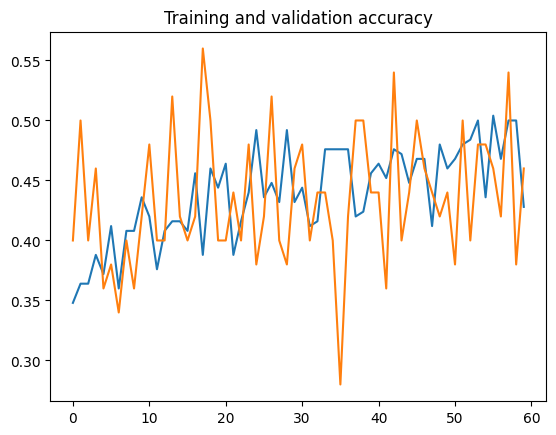

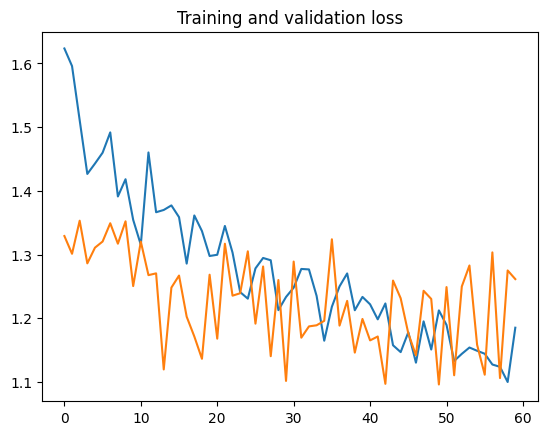

In [ ]:
#Retrieve a list of accuracy results on training and validation data
#Sets for each training epoch
acc = history.history['acc']
val_acc = history.history['val_acc']

#Retrieve a list of results on training and validation data
#Sets for each training epoch
loss = history.history['loss']
val_loss = history.history['val_loss']

#Get number of epochs
epochs = range(len(acc))

#Plot training and validation accuracy per epoch
plt.plot(epochs, acc)
plt.plot(epochs, val_acc)
plt.title('Training and validation accuracy')

plt.figure()

#Plot training and validation loss per epoch
plt.plot(epochs, loss)
plt.plot(epochs, val_loss)
plt.title('Training and validation loss')

# Inference
The classifier should now be ready. Play inference on a new image using `UKmodel.predict`

In [ ]:
import numpy as np
from keras._tf_keras.keras.preprocessing.image import img_to_array, load_img
#Upload a new coin image and try to classify it
fname = "./coins1.jpg" #Update name as needed
img = load_img(fname, target_size=(100, 100))
x = img_to_array(img) #Numpy array with shape (100, 100, 3)
x = x.reshape((1,) + x.shape) #Numpy array with shape (1, 100, 100, 3)
#Rescale by 1/255
x /= 255
#Run the image through the network
prediction = UKmodel.predict(x)
prediction
#Class numbers corresponds to subdirectories (train_datagen.flow_from_directory uses alphabetic order by default)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 610ms/step


array([[3.4620458e-05, 1.9321201e-04, 3.5903427e-06, 1.5376074e-05,
        7.3349962e-05, 5.4224392e-06, 7.2815681e-01, 2.7151766e-01]],
      dtype=float32)